# Лабораторная работа 2 - Агрикультура

Выбери свой вариант из таблички курса и работай дальше с ним.


Вариант А. Сорта подсолнечника по регионам допуска.

https://ru.wikipedia.org/wiki/%D0%9F%D0%BE%D0%B4%D1%81%D0%BE%D0%BB%D0%BD%D0%B5%D1%87%D0%BD%D0%B8%D0%BA

(Таблица связи сортов подсолнечника и регионов допуска).


Вариант B. Сорта картофеля по регионам допуска.

https://ru.wikipedia.org/wiki/%D0%9A%D0%B0%D1%80%D1%82%D0%BE%D1%84%D0%B5%D0%BB%D0%B5%D0%B2%D0%BE%D0%B4%D1%81%D1%82%D0%B2%D0%BE

(Таблица связи сортов картофеля и регионов допуска)

Вариант C. Производство сахарной свёклы по миру.

https://ru.wikipedia.org/wiki/%D0%A1%D0%B0%D1%85%D0%B0%D1%80%D0%BD%D0%B0%D1%8F_%D1%81%D0%B2%D1%91%D0%BA%D0%BB%D0%B0

(Как географические координаты можно брать столицы стран).

Вариант D. Производство зелёного гороха по странам и годам.

https://ru.wikipedia.org/wiki/%D0%93%D0%BE%D1%80%D0%BE%D1%85


Вариант E. Крупнейшие производители сои (тысяч тонн).

https://ru.wikipedia.org/wiki/%D0%A1%D0%BE%D1%8F

Вариант F. Ведущие производители кукурузы (тысяч тонн)

https://ru.wikipedia.org/wiki/%D0%9A%D1%83%D0%BA%D1%83%D1%80%D1%83%D0%B7%D0%B0

Вариант G. Список стран по производству риса

https://ru.wikipedia.org/wiki/%D0%A1%D0%BF%D0%B8%D1%81%D0%BE%D0%BA_%D1%81%D1%82%D1%80%D0%B0%D0%BD_%D0%BF%D0%BE_%D0%BF%D1%80%D0%BE%D0%B8%D0%B7%D0%B2%D0%BE%D0%B4%D1%81%D1%82%D0%B2%D1%83_%D1%80%D0%B8%D1%81%D0%B0

Вариант H. Крупнейшие производители томатов в тысячах тонн

https://ru.wikipedia.org/wiki/%D0%A2%D0%BE%D0%BC%D0%B0%D1%82

Вариант I. Список стран по выращиванию ячменя

https://ru.wikipedia.org/wiki/%D0%A1%D0%BF%D0%B8%D1%81%D0%BE%D0%BA_%D1%81%D1%82%D1%80%D0%B0%D0%BD_%D0%BF%D0%BE_%D0%B2%D1%8B%D1%80%D0%B0%D1%89%D0%B8%D0%B2%D0%B0%D0%BD%D0%B8%D1%8E_%D1%8F%D1%87%D0%BC%D0%B5%D0%BD%D1%8F

Вариант J. Список стран по производству ржи

https://ru.wikipedia.org/wiki/%D0%A1%D0%BF%D0%B8%D1%81%D0%BE%D0%BA_%D1%81%D1%82%D1%80%D0%B0%D0%BD_%D0%BF%D0%BE_%D0%BF%D1%80%D0%BE%D0%B8%D0%B7%D0%B2%D0%BE%D0%B4%D1%81%D1%82%D0%B2%D1%83_%D1%80%D0%B6%D0%B8

In [ ]:
# ВЕСЬ КОД:
from bs4 import BeautifulSoup
import requests
import matplotlib.pyplot as plt
import pandas as pd
from datetime import datetime, timedelta
import time
import plotly.express as px

# PART 1
url = "https://ru.wikipedia.org/wiki/%D0%A1%D0%B0%D1%85%D0%B0%D1%80%D0%BD%D0%B0%D1%8F_%D1%81%D0%B2%D1%91%D0%BA%D0%BB%D0%B0"
response = requests.get(url)
soup = BeautifulSoup(response.text, 'html.parser')
countries = list()
capitals = list()
coords = list()
capitals_name = []
info = []
products = []
all_data = []
for product in soup.find_all('table', class_='wikitable'):
    name = product.find('caption').text.strip()
    if name == "Ведущие производители сахарной свёклы (млн. тонн)":
        href_list = list(product.find_all('a'))[:-2]
        for link in href_list:
            href = "https://ru.wikipedia.org" + link["href"]
            local_response = requests.get(href)
            countries.append(BeautifulSoup(local_response.text, 'html.parser'))

for country in countries:
    trs = country.find_all('tr')
    for tr in trs:
        f1 = tr.find('th')
        if f1 is None:
            continue
        f2 = f1.find('a')
        if f2 is None:
            continue
        if f2.has_attr('title') and f2['title'] == 'Столица':
            href = "https://ru.wikipedia.org" + list(tr.find_all('a'))[1]["href"]
            capitals_name.append(list(tr.find_all('a'))[1].text)
            local_response = requests.get(href)
            capitals.append(BeautifulSoup(local_response.text, 'html.parser'))
for capital in capitals:
    need = capital.find('a', class_ = ["mw-kartographer-maplink", "mw-kartographer-link"])
    coords.append((need['data-lat'], need['data-lon']))
    
data = {}
for product in soup.find_all('table', class_='wikitable'):
    name = product.find('caption').text.strip()
    if name == "Ведущие производители сахарной свёклы (млн. тонн)":
        trs = product.find_all('tr')[1:13]
i = 0
for tr in trs:
    tds = tr.find_all('td')
    data[tds[1].find('span')['data-sort-value']] = float(tds[4].text[:-1].replace(',', '.'))
    all_data.append((i+1, tds[1].find('span')['data-sort-value'], capitals_name[i], coords[i][0],
                     coords[i][1], float(tds[2].text[:-1].replace(',', '.')), float(tds[3].text[:-1].replace(',', '.')), float(tds[4].text[:-1].replace(',', '.'))))
    i = i + 1

df = pd.DataFrame(all_data, columns=['Место', 'Страна', 'Столица', 'Координаты столицы (с.ш.)', 'Координаты столицы (в.д.)', '2014', '2016', '2021'])
df.to_csv('sugar_beet_information.csv', index=False, encoding='utf-8-sig')
print(df)
# PART 2
# График долей за 2021 год
fig, ax = plt.subplots(figsize=(10, 7))
ax.pie(
    data.values(), 
    labels=data.keys(),
    autopct='%1.1f%%',  
    startangle=90,      
    shadow=True,       
)
ax.set_title('Производство свеклы по странам (2021)', fontsize=16)

plt.tight_layout()
plt.show()

# График динамики за 3 года всех стран
fig, ax = plt.subplots(figsize=(12, 8))
for _, row in df.iterrows():
    ax.plot(['2014', '2016', '2021'], [row['2014'], row['2016'], row['2021']], marker='o', label=row['Страна'])

ax.set_title('Динамика урожая сахарной свёклы по странам (млн. тонн)', fontsize=16)
ax.set_xlabel('Год', fontsize=12)
ax.set_ylabel('Урожай (млн. тонн)', fontsize=12)
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize='small')
plt.xticks(['2014', '2016', '2021'])
plt.grid(True)
plt.tight_layout()
plt.show()

# PART 3

key = "" # Послание самому себе: УБРАТЬ (сделано)


coords = df[['Страна', 'Столица', 'Координаты столицы (с.ш.)', 'Координаты столицы (в.д.)']].copy()
coords = coords.reset_index(drop=True)

start_date = datetime(2024, 4, 21)
end_date = datetime(2025, 4, 7)
dates = []

while start_date <= end_date:
    for day in [1, 7, 14, 21, 28]:
        try:
            d = start_date.replace(day=day)
        except ValueError:
            continue
        if start_date <= d <= end_date:
            dates.append(d.strftime('%Y-%m-%d'))
    start_date = (start_date + timedelta(days=32)).replace(day=1)


weather_data = []


for idx, row in coords.iterrows():
    lat, lon = row['Координаты столицы (с.ш.)'], row['Координаты столицы (в.д.)']
    country, capital = row['Страна'], row['Столица']
    for date in dates:
        url = f"http://api.weatherapi.com/v1/history.json?key={key}&q={lat},{lon}&dt={date}&aqi=no"
        response = requests.get(url)
        if response.status_code != 200:
            print(f"Ошибка запроса для {capital} ({date}): {response.status_code}")
            continue
        data = response.json()
        try:
            day_info = data['forecast']['forecastday'][0]['day']
            weather_data.append({
                'Страна': country,
                'Столица': capital,
                'Дата': date,
                'Средняя температура (C)': day_info['avgtemp_c'],
                'Минимальная температура (C)': day_info['mintemp_c'],
                'Максимальная температура (C)': day_info['maxtemp_c']
            })
        except KeyError:
            print(f"Нет данных для {capital} на {date}")
        time.sleep(1)  


weather_df = pd.DataFrame(weather_data)


weather_df['Месяц'] = pd.to_datetime(weather_df['Дата']).dt.to_period('M')


monthly_stats = weather_df.groupby(['Страна', 'Столица', 'Месяц']).agg({
    'Средняя температура (C)': 'mean',
    'Минимальная температура (C)': 'min',
    'Максимальная температура (C)': 'max'
}).reset_index()

weather_df.to_csv('raw_weather_data.csv', index=False, encoding='utf-8-sig')
monthly_stats.to_csv('monthly_weather_summary.csv', index=False, encoding='utf-8-sig')

print(monthly_stats.head())

# PART 4


# Погода
weather_df = pd.read_csv("raw_weather_data.csv")
weather_df['Дата'] = pd.to_datetime(weather_df['Дата'])
weather_df['Месяц'] = weather_df['Дата'].dt.to_period('M').astype(str)

df = pd.read_csv("sugar_beet_information.csv")


df = df.rename(columns={
    'Координаты столицы (с.ш.)': 'lat',
    'Координаты столицы (в.д.)': 'lon'
})


weather_df = weather_df.merge(df[['Столица', 'lat', 'lon']], on='Столица', how='left')

agg_weather_df = (weather_df.groupby(['Страна', 'Столица', 'Месяц', 'lat', 'lon'], as_index=False).agg({
        'Средняя температура (C)': 'mean',
        'Минимальная температура (C)': 'min',
        'Максимальная температура (C)': 'max'
    })
)

fig_temp = px.scatter_geo(
    agg_weather_df,
    lat='lat',
    lon='lon',
    color='Средняя температура (C)',
    size=agg_weather_df['Средняя температура (C)'].abs() + 1,
    animation_frame='Месяц',
    hover_name='Столица',
    projection='natural earth',
    title='Средняя температура в столицах (по месяцам)',
    color_continuous_scale='RdBu_r',
    range_color=(-30, 40),
    size_max=30
)
fig_temp.update_layout(legend_title_text='Температура (°C)')
fig_temp.show()
# Урожай



df['lat'] = df['lat'].astype(float)
df['lon'] = df['lon'].astype(float)

df_long = df.melt(
    id_vars=['Страна', 'Столица', 'lat', 'lon'],
    value_vars=['2014', '2016', '2021'],
    var_name='Год',
    value_name='Урожай'
)

fig_crop = px.scatter_geo(
    df_long,
    lat='lat',
    lon='lon',
    color='Урожай',
    size='Урожай',
    hover_name='Страна',
    animation_frame='Год',
    projection='natural earth',
    title='Урожай сахарной свёклы по странам в течение 7 лет',
    color_continuous_scale='YlGn',
)

fig_crop.update_layout(legend_title_text='Урожай (млн тонн)')
fig_crop.show()


#PART 5


def is_parsable(url):
    headers = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)"
    }
    try:
        response = requests.get(url, headers=headers, timeout=10)
        if response.status_code != 200:
            print(f"[{url}] Статус код: {response.status_code}")
            return False
        soup = BeautifulSoup(response.text, 'html.parser')
        title = soup.title.string if soup.title else "нет тега <title>"
        print(f"[{url}] Парсинг возможен. Title: {title}")
        return True
    except Exception as e:
        print(f"[{url}] Ошибка: {e}")
        return False
urls = [
    "https://agroserver.ru/search/%D1%81%D0%B0%D1%85%D0%B0%D1%80%D0%BD%D0%B0%D1%8F+%D1%81%D0%B2%D1%91%D0%BA%D0%BB%D0%B0/1/0/0/0/0/1/", 
    "https://www.rusagrogroup.ru/business/sugar/",  
    "https://www.auchan.ru/catalog/sakharnaya-svekla",  
    "https://www.agroxxi.ru/selhoztekhnika/dlya-svekly/",  
    "https://www.amazon.com/s?k=sugar+beet",
    "https://market.yandex.ru/search?text=сахарная%20свекла",
    "https://www.ozon.ru/category/semena-saharnoy-svekly/",
    "https://www.avito.ru/all?q=сахарная+свекла",
    "https://semena.ru/catalog/semena/ovoshchi/svekla/?srsltid=AfmBOoptYNsK5_F8xl5em5DL_J4MFDFve4SINN9PJYXDj4YOAFyMG33D"
]

for url in urls:
    is_parsable(url)


#PART 6

headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/122.0.0.0 Safari/537.36"
}

def parse_semena_ru(page_limit=3):
    base_url = "https://semena.ru/catalog/semena/ovoshchi/svekla/"
    data = []

    for page in range(1, page_limit + 1):
        url = f"{base_url}?PAGEN_1={page}"
        response = requests.get(url, headers=headers)
        if response.status_code != 200:
            print(f"Ошибка на странице {page}")
            continue

        soup = BeautifulSoup(response.text, "html.parser")
        items = soup.find_all("div", class_="b-product__body")

        for item in items:
            try:
                title = item.find("a", class_="b-product__title").get_text(strip=True)
            except:
                title = None

            try:
                price = item.find("span", class_="price").get_text(strip=True)
                if price == None:
                    price = item.find("span", class_="discount-price no-discount-price").get_text(strip=True)
            except:
                price = None

            try:
                article = item.find("div", class_="b-product-info__container").get_text(strip=True)[:-9]
            except:
                article = None

            data.append({
                "Название": title,
                "Цена": price,
                "Артикул": article
            })

        time.sleep(1)  

    return pd.DataFrame(data)


df = parse_semena_ru(page_limit=5)  
df.to_csv("semena_svekla.csv", index=False, encoding="utf-8-sig")
print(df.head())

# Топ 10 дорожайших семян свеклы
df["Цена (число)"] = df["Цена"].str.replace("₽", "").str.replace(" ", "").astype(float)
df.sort_values("Цена (число)", ascending=False).head(10).plot.bar(x="Название", y="Цена (число)", figsize=(10, 5))
plt.ylabel("Цена, ₽")
plt.tight_layout()
plt.show()

: 

## Часть 1. Скачай данные из табличек + информацию о географических данных (широта и долгота) центра данного региона + подчисти датасет. 2 балла.

In [ ]:
# PART 1
url = "https://ru.wikipedia.org/wiki/%D0%A1%D0%B0%D1%85%D0%B0%D1%80%D0%BD%D0%B0%D1%8F_%D1%81%D0%B2%D1%91%D0%BA%D0%BB%D0%B0"
response = requests.get(url)
soup = BeautifulSoup(response.text, 'html.parser')
countries = list()
capitals = list()
coords = list()
capitals_name = []
info = []
products = []
all_data = []
for product in soup.find_all('table', class_='wikitable'):
    name = product.find('caption').text.strip()
    if name == "Ведущие производители сахарной свёклы (млн. тонн)":
        href_list = list(product.find_all('a'))[:-2]
        for link in href_list:
            href = "https://ru.wikipedia.org" + link["href"]
            local_response = requests.get(href)
            countries.append(BeautifulSoup(local_response.text, 'html.parser'))

for country in countries:
    trs = country.find_all('tr')
    for tr in trs:
        f1 = tr.find('th')
        if f1 is None:
            continue
        f2 = f1.find('a')
        if f2 is None:
            continue
        if f2.has_attr('title') and f2['title'] == 'Столица':
            href = "https://ru.wikipedia.org" + list(tr.find_all('a'))[1]["href"]
            capitals_name.append(list(tr.find_all('a'))[1].text)
            local_response = requests.get(href)
            capitals.append(BeautifulSoup(local_response.text, 'html.parser'))
for capital in capitals:
    need = capital.find('a', class_ = ["mw-kartographer-maplink", "mw-kartographer-link"])
    coords.append((need['data-lat'], need['data-lon']))
    
data = {}
for product in soup.find_all('table', class_='wikitable'):
    name = product.find('caption').text.strip()
    if name == "Ведущие производители сахарной свёклы (млн. тонн)":
        trs = product.find_all('tr')[1:13]
i = 0
for tr in trs:
    tds = tr.find_all('td')
    data[tds[1].find('span')['data-sort-value']] = float(tds[4].text[:-1].replace(',', '.'))
    all_data.append((i+1, tds[1].find('span')['data-sort-value'], capitals_name[i], coords[i][0],
                     coords[i][1], float(tds[2].text[:-1].replace(',', '.')), float(tds[3].text[:-1].replace(',', '.')), float(tds[4].text[:-1].replace(',', '.'))))
    i = i + 1

df = pd.DataFrame(all_data, columns=['Место', 'Страна', 'Столица', 'Координаты столицы (с.ш.)', 'Координаты столицы (в.д.)', '2014', '2016', '2021'])
df.to_csv('sugar_beet_information.csv', index=False, encoding='utf-8-sig')
print(df)

: 

## Часть 2. Графики/диаграммы - 1 балл.

Визуализируй графики без учёта карт/координат (можно по годам, можно barplot - по категориям). Нужно сделать не менее 2 различных **информативных** графика с учётом данных из части 1.

In [ ]:
# # PART 2
# График долей за 2021 год
fig, ax = plt.subplots(figsize=(10, 7))
ax.pie(
    data.values(), 
    labels=data.keys(),
    autopct='%1.1f%%',  
    startangle=90,      
    shadow=True,       
)
ax.set_title('Производство свеклы по странам (2021)', fontsize=16)

plt.tight_layout()
plt.show()

# График динамики за 3 года всех стран
fig, ax = plt.subplots(figsize=(12, 8))
for _, row in df.iterrows():
    ax.plot(['2014', '2016', '2021'], [row['2014'], row['2016'], row['2021']], marker='o', label=row['Страна'])

ax.set_title('Динамика урожая сахарной свёклы по странам (млн. тонн)', fontsize=16)
ax.set_xlabel('Год', fontsize=12)
ax.set_ylabel('Урожай (млн. тонн)', fontsize=12)
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize='small')
plt.xticks(['2014', '2016', '2021'])
plt.grid(True)
plt.tight_layout()
plt.show()

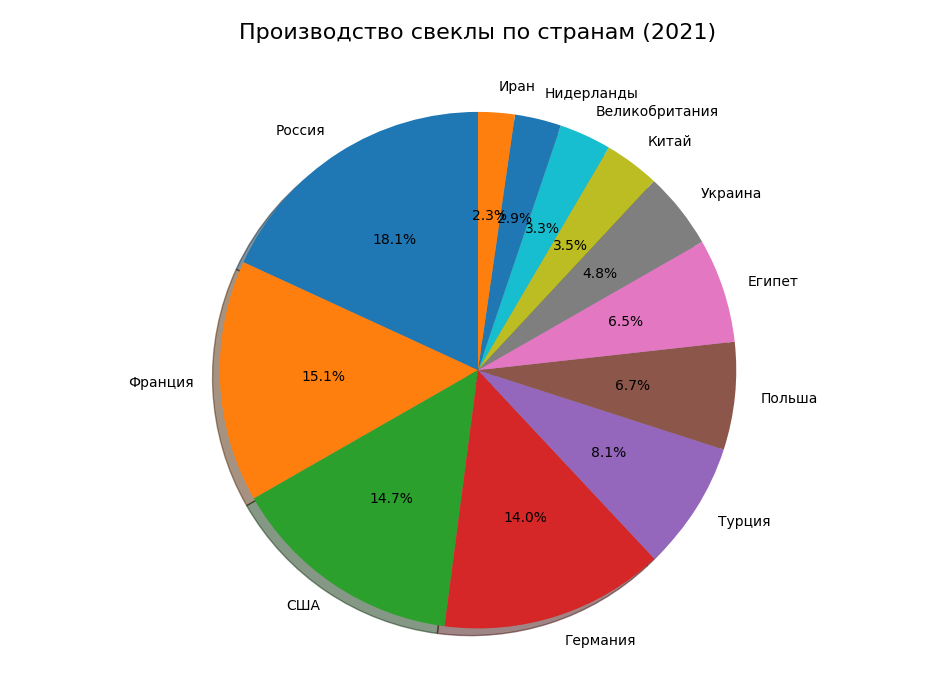
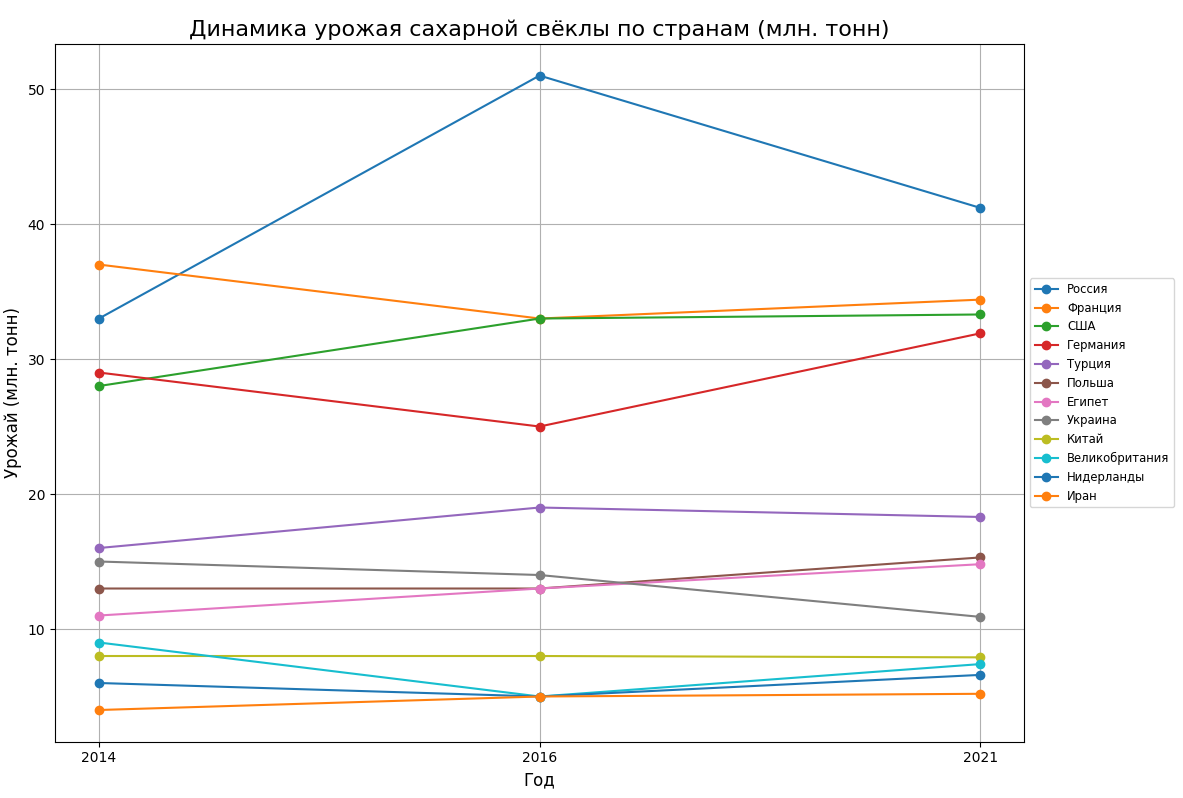

<font color="violet"> Какие выводы можно сделать из этих графиков? </font>

Выводы: Вообще, строго говоря 1. Какая доля свеклы по миру где производится на 2021 год и как поменялось проивзодство свёклы за 7 лет. Вообще, может быть сопоставить с гео-политическими факторами или природными процессами, которые влияют на способность государств растить оный вид сельскохозяйственной культуры. Но это другая история (это больше аналитика и экономика, чем конкретно это задание).

## Часть 3. Сбор данных о погоде через API - 2 балла.

Получи данные о погоде в географических точках. полученных в части 1 этой лабораторной работы, через API https://www.weatherapi.com/.

Тебе нужно получить информацию о том, какая температура в этих точках была каждый месяц последнего года в следующие даты: 1, 7, 14, 21, 28. Посчитай средние температуры, минимумы и максимумы за месяц.

Получается, самой ранней датой будет 21-04-2024, самой поздней - 2025-04-07.


**Замечание 1.** Если у тебя больше 25 географических точек, то можно выбрать 25 точек из текущего набора данных (например, топ-25 производителей данного товара).

**Замечание 2.** Обрати внимание, что надо работать именно с градусами Цельсия.

<font color='red'> Не забудь удалить API ключ доступа перед отправкой на проверку. Ежедневно 20 морских котиков умирают из-за того, что нерадивые программисты забывают удалить приватный API ключ доступа и заливают код в публичный репозиторий. После этого китайские хакеры получают все доступы после того, как воспользовавшись кодом из части 4 этой лабораторной, скрапят эти ключи из публичных репозиториев. Если ты не удалишь ключ - мы снимем очень много баллов. </font>

Оставь вместо строчки `key = "some_api_key_example"` строчку `key = ""`.

In [ ]:
# PART 3

key = "" # Послание самому себе: УБРАТЬ (сделано)


coords = df[['Страна', 'Столица', 'Координаты столицы (с.ш.)', 'Координаты столицы (в.д.)']].copy()
coords = coords.reset_index(drop=True)

start_date = datetime(2024, 4, 21)
end_date = datetime(2025, 4, 7)
dates = []

while start_date <= end_date:
    for day in [1, 7, 14, 21, 28]:
        try:
            d = start_date.replace(day=day)
        except ValueError:
            continue
        if start_date <= d <= end_date:
            dates.append(d.strftime('%Y-%m-%d'))
    start_date = (start_date + timedelta(days=32)).replace(day=1)


weather_data = []


for idx, row in coords.iterrows():
    lat, lon = row['Координаты столицы (с.ш.)'], row['Координаты столицы (в.д.)']
    country, capital = row['Страна'], row['Столица']
    for date in dates:
        url = f"http://api.weatherapi.com/v1/history.json?key={key}&q={lat},{lon}&dt={date}&aqi=no"
        response = requests.get(url)
        if response.status_code != 200:
            print(f"Ошибка запроса для {capital} ({date}): {response.status_code}")
            continue
        data = response.json()
        try:
            day_info = data['forecast']['forecastday'][0]['day']
            weather_data.append({
                'Страна': country,
                'Столица': capital,
                'Дата': date,
                'Средняя температура (C)': day_info['avgtemp_c'],
                'Минимальная температура (C)': day_info['mintemp_c'],
                'Максимальная температура (C)': day_info['maxtemp_c']
            })
        except KeyError:
            print(f"Нет данных для {capital} на {date}")
        time.sleep(1)  


weather_df = pd.DataFrame(weather_data)


weather_df['Месяц'] = pd.to_datetime(weather_df['Дата']).dt.to_period('M')


monthly_stats = weather_df.groupby(['Страна', 'Столица', 'Месяц']).agg({
    'Средняя температура (C)': 'mean',
    'Минимальная температура (C)': 'min',
    'Максимальная температура (C)': 'max'
}).reset_index()

weather_df.to_csv('raw_weather_data.csv', index=False, encoding='utf-8-sig')
monthly_stats.to_csv('monthly_weather_summary.csv', index=False, encoding='utf-8-sig')

print(monthly_stats.head())

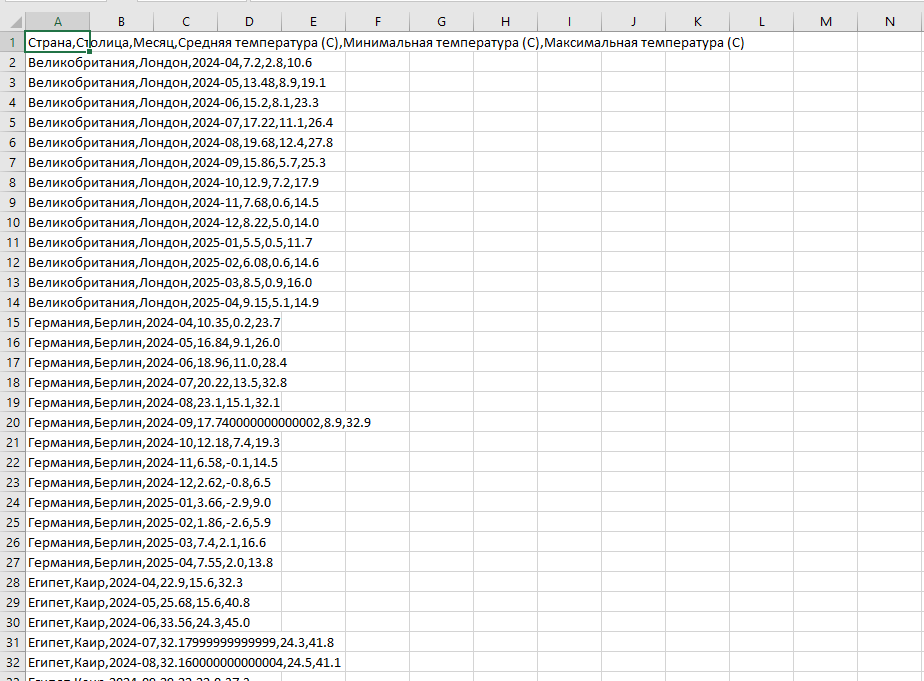

## Часть 4. Визуализируй данные о погоде и на картах при помощи plotly - 3 балла.

Нужно построить 2 **информативные** карты - одну для погоды, другую - для информации о выращиваемом урожае в данном регионе.

Хотя бы одна карта должна иметь информацию о разных годах (т.е. о том, как параметр менялся с течением времени)

In [ ]:
# PART 4


# Погода
weather_df = pd.read_csv("raw_weather_data.csv")
weather_df['Дата'] = pd.to_datetime(weather_df['Дата'])
weather_df['Месяц'] = weather_df['Дата'].dt.to_period('M').astype(str)

df = pd.read_csv("sugar_beet_information.csv")


df = df.rename(columns={
    'Координаты столицы (с.ш.)': 'lat',
    'Координаты столицы (в.д.)': 'lon'
})


weather_df = weather_df.merge(df[['Столица', 'lat', 'lon']], on='Столица', how='left')

agg_weather_df = (weather_df.groupby(['Страна', 'Столица', 'Месяц', 'lat', 'lon'], as_index=False).agg({
        'Средняя температура (C)': 'mean',
        'Минимальная температура (C)': 'min',
        'Максимальная температура (C)': 'max'
    })
)

fig_temp = px.scatter_geo(
    agg_weather_df,
    lat='lat',
    lon='lon',
    color='Средняя температура (C)',
    size=agg_weather_df['Средняя температура (C)'].abs() + 1,
    animation_frame='Месяц',
    hover_name='Столица',
    projection='natural earth',
    title='Средняя температура в столицах (по месяцам)',
    color_continuous_scale='RdBu_r',
    range_color=(-30, 40),
    size_max=30
)
fig_temp.update_layout(legend_title_text='Температура (°C)')
fig_temp.show()
# Урожай



df['lat'] = df['lat'].astype(float)
df['lon'] = df['lon'].astype(float)

df_long = df.melt(
    id_vars=['Страна', 'Столица', 'lat', 'lon'],
    value_vars=['2014', '2016', '2021'],
    var_name='Год',
    value_name='Урожай'
)

fig_crop = px.scatter_geo(
    df_long,
    lat='lat',
    lon='lon',
    color='Урожай',
    size='Урожай',
    hover_name='Страна',
    animation_frame='Год',
    projection='natural earth',
    title='Урожай сахарной свёклы по странам в течение 7 лет',
    color_continuous_scale='YlGn',
)

fig_crop.update_layout(legend_title_text='Урожай (млн тонн)')
fig_crop.show()

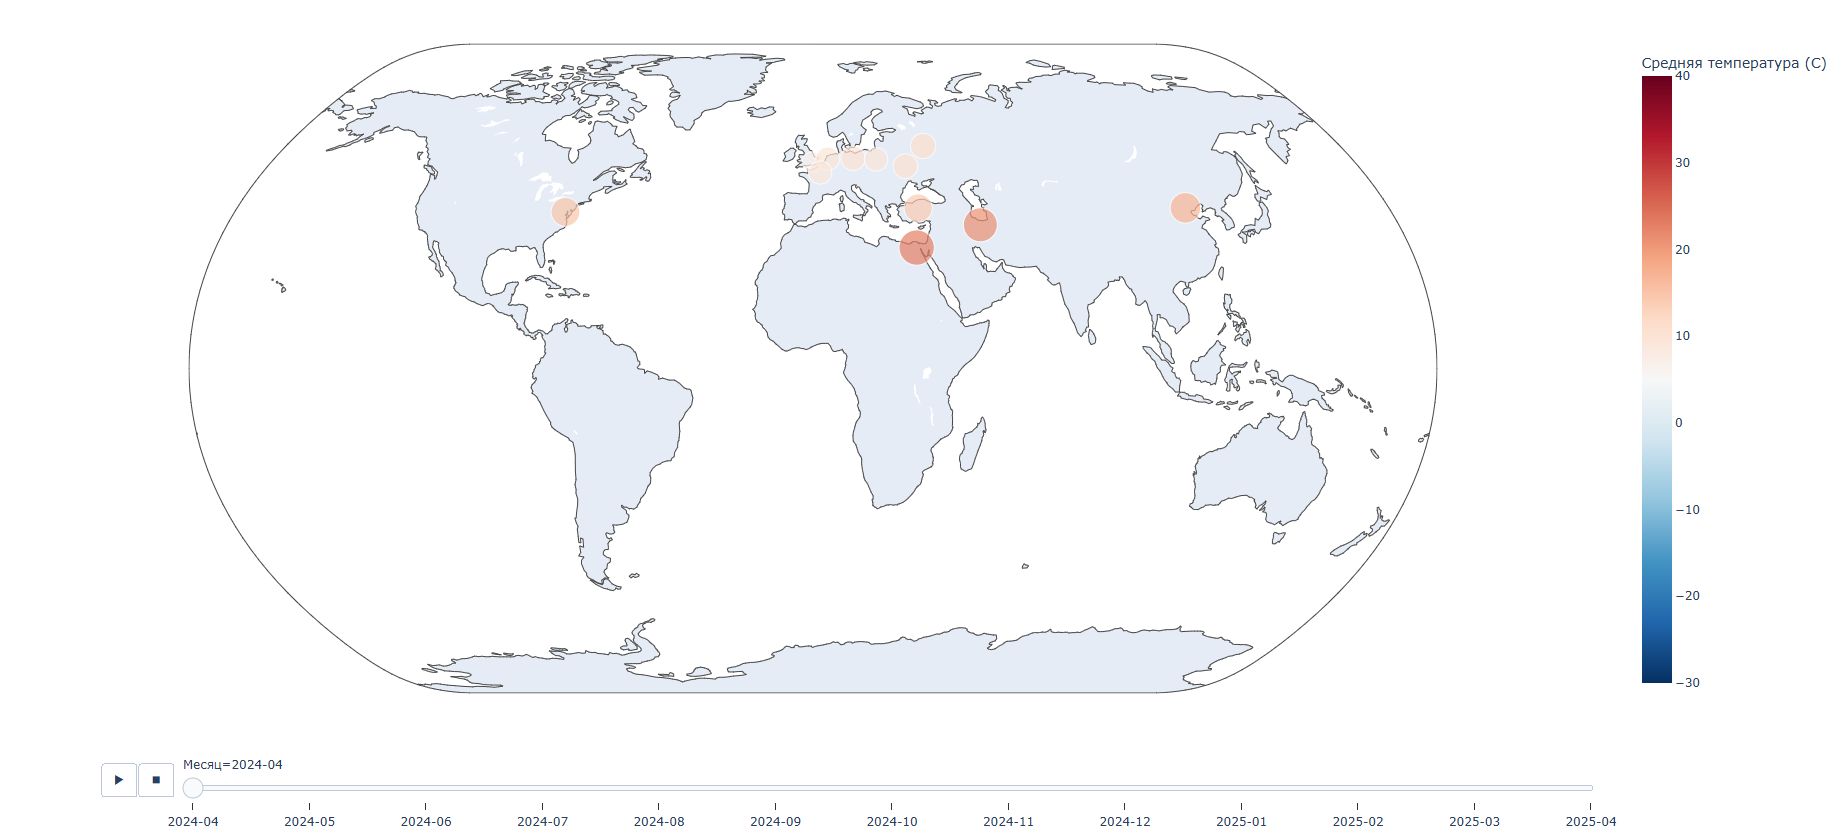
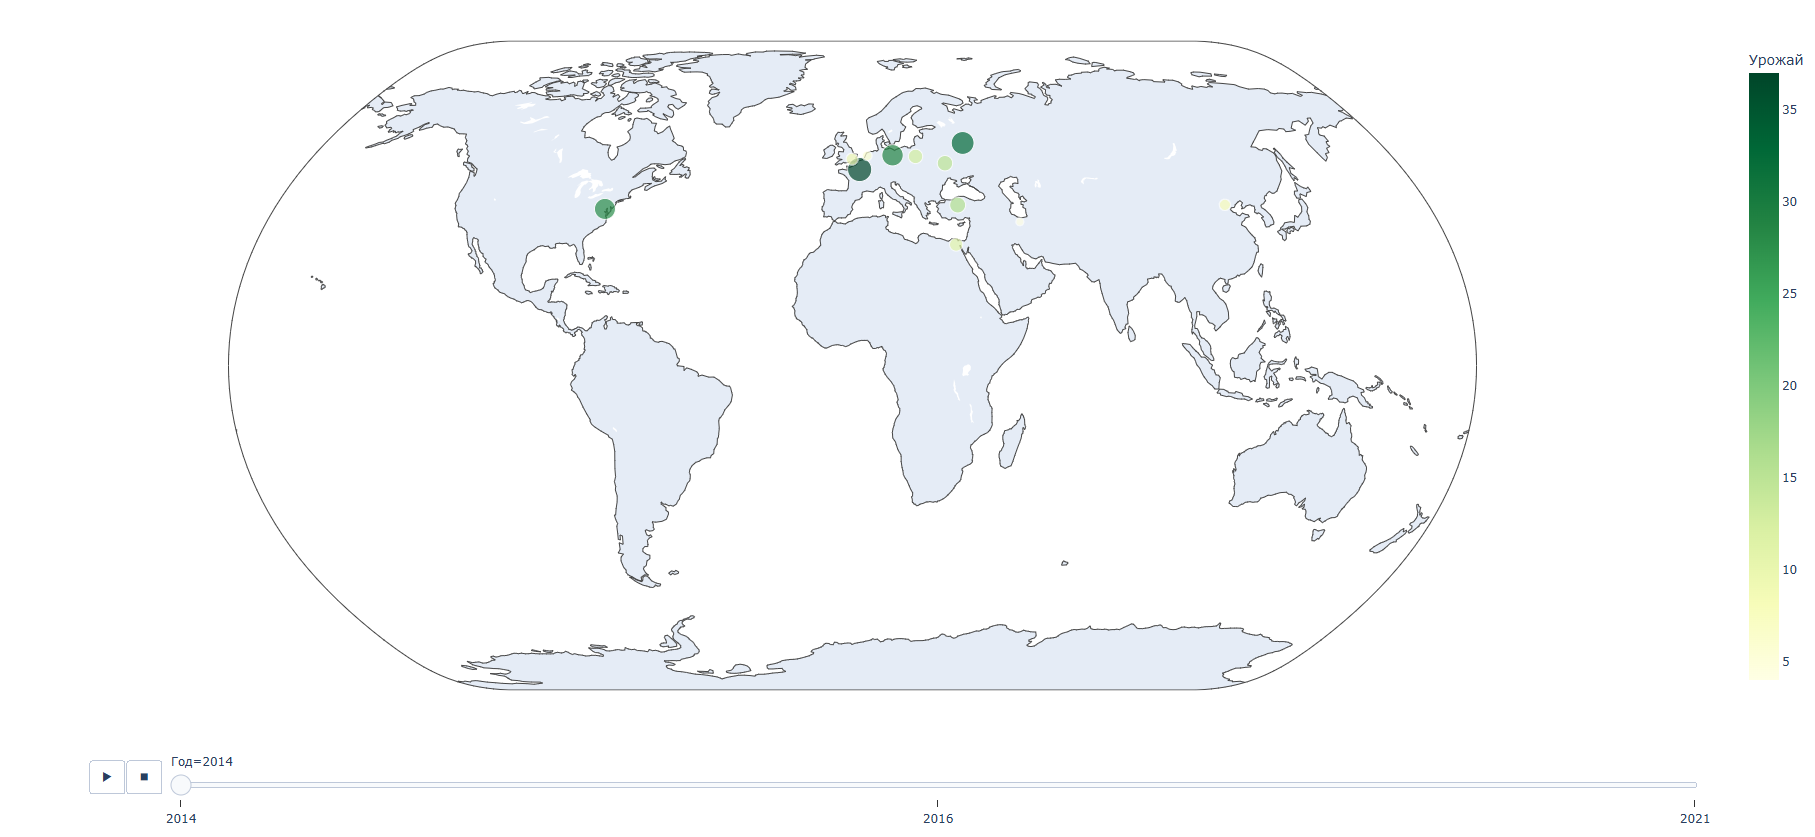

## Часть 5. Найди сайт магазина с информацией о товарах, как-либо связанными с твоей таблицей сверху. - 1 балл.

Если у вас таблица про кукурузу (например), то можно либо поискать стоимость килограмма кукурузы различных сортов, или изделий из кукурузы (<i>"Veronica, don't forget thE CORN NUTS. It's not a party without corn nuts!!" - Heather Chandler</i>), или изделия, связанные с выращиванием кукурузы (машина для сбора кукурузных початков) - на ваш вкус и фантазию.


Напиши функцию, которая проверяет, даёт ли сайт возможность парсить себя при помощи библиотек `requests` и `bs4` - и прогони несколько сайтов через неё, пока не найдёшь тот самый.

Опиши, какие сайты не получается спарсить - что с ними не так?

In [ ]:
#PART 5


def is_parsable(url):
    headers = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)"
    }
    try:
        response = requests.get(url, headers=headers, timeout=10)
        if response.status_code != 200:
            print(f"[{url}] Статус код: {response.status_code}")
            return False
        soup = BeautifulSoup(response.text, 'html.parser')
        title = soup.title.string if soup.title else "нет тега <title>"
        print(f"[{url}] Парсинг возможен. Title: {title}")
        return True
    except Exception as e:
        print(f"[{url}] Ошибка: {e}")
        return False
urls = [
    "https://agroserver.ru/search/%D1%81%D0%B0%D1%85%D0%B0%D1%80%D0%BD%D0%B0%D1%8F+%D1%81%D0%B2%D1%91%D0%BA%D0%BB%D0%B0/1/0/0/0/0/1/", 
    "https://www.rusagrogroup.ru/business/sugar/",  
    "https://www.auchan.ru/catalog/sakharnaya-svekla",  
    "https://www.agroxxi.ru/selhoztekhnika/dlya-svekly/",  
    "https://www.amazon.com/s?k=sugar+beet",
    "https://market.yandex.ru/search?text=сахарная%20свекла",
    "https://www.ozon.ru/category/semena-saharnoy-svekly/",
    "https://www.avito.ru/all?q=сахарная+свекла",
    "https://semena.ru/catalog/semena/ovoshchi/svekla/?srsltid=AfmBOoptYNsK5_F8xl5em5DL_J4MFDFve4SINN9PJYXDj4YOAFyMG33D"
]

for url in urls:
    is_parsable(url)


<font color="violet"> TODO </font>

## Часть 6. Сбор данных о товарах + анализ (3 балла).

Получи информацию о товарах из данного магазина и собери из них Dataframe. Нам нужна информация о названиях товаров, стоимости, потенциально - производителе. Возможно, стоит собрать и другие данные, которые будут представлены на сайте.

Построй хотя бы один информативный график и напиши выводы о том, какие товары представлены в магазине и есть ли какая-то взаимосвязь между товарами и предыдущими частями этой лабораторной работы.

In [ ]:
#PART 6

headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/122.0.0.0 Safari/537.36"
}

def parse_semena_ru(page_limit=3):
    base_url = "https://semena.ru/catalog/semena/ovoshchi/svekla/"
    data = []

    for page in range(1, page_limit + 1):
        url = f"{base_url}?PAGEN_1={page}"
        response = requests.get(url, headers=headers)
        if response.status_code != 200:
            print(f"Ошибка на странице {page}")
            continue

        soup = BeautifulSoup(response.text, "html.parser")
        items = soup.find_all("div", class_="b-product__body")

        for item in items:
            try:
                title = item.find("a", class_="b-product__title").get_text(strip=True)
            except:
                title = None

            try:
                price = item.find("span", class_="price").get_text(strip=True)
                if price == None:
                    price = item.find("span", class_="discount-price no-discount-price").get_text(strip=True)
            except:
                price = None

            try:
                article = item.find("div", class_="b-product-info__container").get_text(strip=True)[:-9]
            except:
                article = None

            data.append({
                "Название": title,
                "Цена": price,
                "Артикул": article
            })

        time.sleep(1)  

    return pd.DataFrame(data)


df = parse_semena_ru(page_limit=5)  
df.to_csv("semena_svekla.csv", index=False, encoding="utf-8-sig")
print(df.head())

# Топ 10 дорожайших семян свеклы
df["Цена (число)"] = df["Цена"].str.replace("₽", "").str.replace(" ", "").astype(float)
df.sort_values("Цена (число)", ascending=False).head(10).plot.bar(x="Название", y="Цена (число)", figsize=(10, 5))
plt.ylabel("Цена, ₽")
plt.tight_layout()
plt.show()

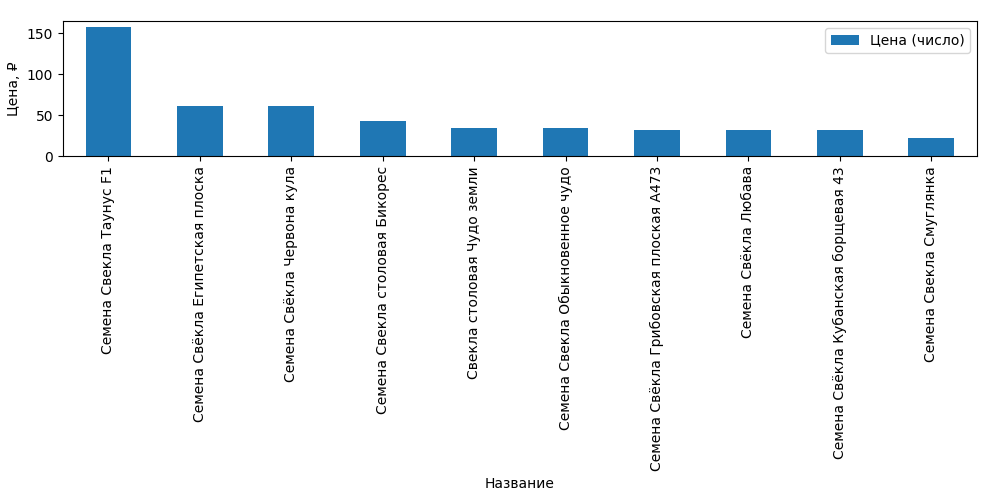

<font color="violet"> TODO </font>

## Часть 6. БОНУСНАЯ. 5 баллов.

**ВМЕСТО** части 6 сверху можно сделать эту.

Тут надо спарсить данные сайта с динамическим контентом при помощи библиотеки `Selenium`.

Задача аналогичная - получить базовую информацию о товарах, оформить из них DataFrame, подчистить данные, если надо и построить график и выводы.

<font color="violet"> TODO </font>